## 📦 Step 1 — Install Dependencies

In [ ]:
# Install required libraries (run once)
!pip install scikit-learn pandas numpy matplotlib seaborn joblib

## 📚 Step 2 — Import Libraries

We import tools for:
- **Data handling:** pandas, numpy
- **Machine Learning:** scikit-learn (TF-IDF, classifiers, metrics)
- **Visualization:** matplotlib, seaborn

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import re
import joblib

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, f1_score
)
from sklearn.model_selection import cross_val_score

warnings.filterwarnings('ignore')
%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


## 📂 Step 3 — Load the Dataset

The data uses ` ::: ` as a separator with columns:
- **Train:** ID · Title · Genre · Description
- **Test:** ID · Title · Description

> ⚠️ Make sure `train_data.txt`, `test_data.txt`, and `test_data_solution.txt` are in the same folder as this notebook.

In [ ]:
# Load training data
train = pd.read_csv(
    'train_data.txt',
    sep=' ::: ',
    header=None,
    names=['id', 'title', 'genre', 'description'],
    engine='python',
    on_bad_lines='skip'
).dropna(subset=['description', 'genre'])

# Load test data (no labels)
test = pd.read_csv(
    'test_data.txt',
    sep=' ::: ',
    header=None,
    names=['id', 'title', 'description'],
    engine='python',
    on_bad_lines='skip'
).dropna(subset=['description'])

# Load test solution (ground truth labels for evaluation)
solution = pd.read_csv(
    'test_data_solution.txt',
    sep=' ::: ',
    header=None,
    names=['id', 'title', 'genre', 'description'],
    engine='python',
    on_bad_lines='skip'
).dropna(subset=['genre'])

print(f'✅ Train samples  : {len(train):,}')
print(f'✅ Test samples   : {len(test):,}')
print(f'✅ Unique genres  : {train["genre"].nunique()}')
print(f'\n📋 All genres: {sorted(train["genre"].unique())}')

✅ Train samples  : 54,214
✅ Test samples   : 54,200
✅ Unique genres  : 27

📋 All genres: ['action', 'adult', 'adventure', 'animation', 'biography', 'comedy', 'crime', 'documentary', 'drama', 'family', 'fantasy', 'game-show', 'history', 'horror', 'music', 'musical', 'mystery', 'news', 'reality-tv', 'romance', 'sci-fi', 'short', 'sport', 'talk-show', 'thriller', 'war', 'western']


## 📊 Step 4 — Exploratory Data Analysis (EDA)

Let's understand the dataset before modelling:
- How many movies per genre?
- Is the data balanced or imbalanced?
- What does the raw text look like?

In [ ]:
# Preview the training data
print('First 3 rows of training data:')
train[['title', 'genre', 'description']].head(3)

First 3 rows of training data:


,title,genre,description
0,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...


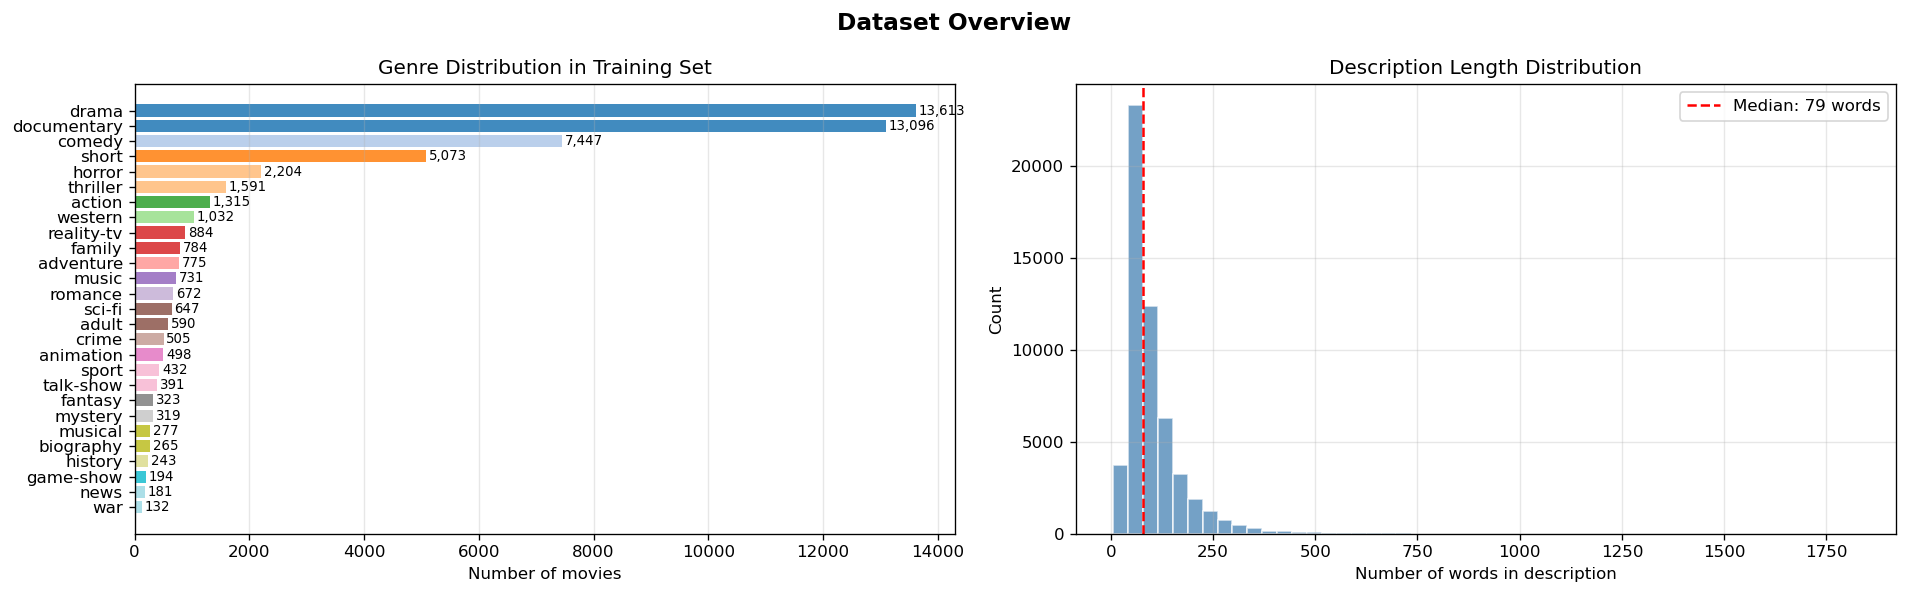


⚠️  Class imbalance: 13613 (drama) vs 132 (war) — 103x difference!


In [ ]:
# Genre distribution + description length
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

genre_counts = train['genre'].value_counts()
colors = plt.cm.tab20(np.linspace(0, 1, len(genre_counts)))
bars = axes[0].barh(genre_counts.index, genre_counts.values, color=colors, alpha=0.85)
axes[0].set_xlabel('Number of movies')
axes[0].set_title('Genre Distribution in Training Set')
axes[0].invert_yaxis()
for bar, val in zip(bars, genre_counts.values):
    axes[0].text(val + 50, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8)
axes[0].grid(axis='x', alpha=0.3)

train['desc_len'] = train['description'].apply(lambda x: len(str(x).split()))
axes[1].hist(train['desc_len'], bins=50, color='steelblue', alpha=0.75, edgecolor='white')
axes[1].set_xlabel('Number of words in description')
axes[1].set_ylabel('Count')
axes[1].set_title('Description Length Distribution')
axes[1].axvline(train['desc_len'].median(), color='red', linestyle='--',
                label=f"Median: {train['desc_len'].median():.0f} words")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle('Dataset Overview', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n⚠️  Class imbalance: {genre_counts.max()} (drama) vs {genre_counts.min()} ({genre_counts.idxmin()}) — {genre_counts.max()//genre_counts.min()}x difference!')

## 🔧 Step 5 — Text Preprocessing

Before feeding text to a model, we clean it:

1. **Lowercase** — "Killer" and "killer" should be the same word
2. **Remove punctuation and numbers** — they add noise
3. **Collapse whitespace** — remove extra spaces
4. **Combine title + description** — the title carries strong genre signals (e.g. "Space Odyssey" → sci-fi)

In [ ]:
def clean_text(text):
    """
    Clean raw text:
    - Convert to lowercase
    - Remove punctuation and numbers
    - Collapse multiple spaces into one
    """
    text = str(text).lower()
    text = re.sub(r'[^a-z\s]', ' ', text)   # keep only letters and spaces
    text = re.sub(r'\s+', ' ', text).strip() # collapse whitespace
    return text

# Apply cleaning and combine title + description
train['features']    = train['title'].apply(clean_text) + ' ' + train['description'].apply(clean_text)
test['features']     = test['title'].apply(clean_text)  + ' ' + test['description'].apply(clean_text)
solution['features'] = solution['title'].apply(clean_text) + ' ' + solution['description'].apply(clean_text)

# Define X (features) and y (labels)
X_train = train['features']
y_train = train['genre']
X_test  = solution['features']
y_test  = solution['genre']

# Show a before/after example
ex_title = train['title'].iloc[0]
ex_desc  = train['description'].iloc[0]
print('BEFORE:')
print(f'  Title : {ex_title}')
print(f'  Desc  : {ex_desc[:100]}...')
print('\nAFTER cleaning:')
print(f'  {clean_text(ex_title + " " + ex_desc)[:120]}...')

BEFORE:
  Title : Oscar et la dame rose (2009)
  Desc  : Listening in to a conversation between his doctor and parents, 10-year-old Oscar learns what nobody ...

AFTER cleaning:
  oscar et la dame rose listening in to a conversation between his doctor and parents year old oscar learns what nobody ha...


## 🔢 Step 6 — TF-IDF Vectorisation

**What is TF-IDF?**

TF-IDF stands for **Term Frequency – Inverse Document Frequency**. It converts text into numbers by scoring each word:

- **TF (Term Frequency):** How often does this word appear in *this* movie's description?
- **IDF (Inverse Document Frequency):** How *rare* is this word across *all* movies?

Words like `gunslinger`, `saloon`, `outlaw` appear often in westerns but rarely elsewhere → high TF-IDF → strong genre signal.

| Parameter | Value | Reason |
|---|---|---|
| `ngram_range=(1,2)` | Unigrams + bigrams | "serial killer" is more meaningful than "serial" + "killer" separately |
| `max_features=50000` | Top 50K words | Limits memory, keeps most important words |
| `sublinear_tf=True` | Log scaling | Prevents very long descriptions from dominating |
| `min_df=3` | Min 3 docs | Drops ultra-rare noise words |

In [ ]:
TFIDF_PARAMS = dict(
    ngram_range=(1, 2),       # unigrams and bigrams
    max_features=50_000,      # keep top 50,000 features
    sublinear_tf=True,        # apply log(1+tf) scaling
    min_df=3,                 # ignore words in < 3 documents
    strip_accents='unicode',  # normalise accented characters
    analyzer='word'
)

print('✅ TF-IDF configuration ready')
for k, v in TFIDF_PARAMS.items():
    print(f'   {k:<20}: {v}')

✅ TF-IDF configuration ready
   ngram_range         : (1, 2)
   max_features        : 50000
   sublinear_tf        : True
   min_df              : 3
   strip_accents       : unicode
   analyzer            : word


## 🤖 Step 7 — Define ML Pipelines

We test three classifiers, each in a Pipeline (TF-IDF → Classifier):

| Model | How it works |
|---|---|
| **Linear SVM** | Finds the best hyperplane to separate genres in high-dimensional space |
| **Logistic Regression** | Estimates probability of each genre and picks the highest |
| **Complement Naive Bayes** | Probabilistic model; good for imbalanced text data |

In [ ]:
models = {
    'Linear SVM': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LinearSVC(C=0.5, max_iter=2000))
    ]),
    'Logistic Regression': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   LogisticRegression(C=5, max_iter=1000, solver='lbfgs', n_jobs=-1))
    ]),
    'Complement Naive Bayes': Pipeline([
        ('tfidf', TfidfVectorizer(**TFIDF_PARAMS)),
        ('clf',   ComplementNB(alpha=0.1))
    ]),
}

print(f'✅ {len(models)} model pipelines defined')
for name in models:
    print(f'   • {name}')

✅ 3 model pipelines defined
   • Linear SVM
   • Logistic Regression
   • Complement Naive Bayes


## 🏋️ Step 8 — Train All Models & Evaluate on Test Set

In [ ]:
results = {}

for name, pipe in models.items():
    print(f'\n⏳ Training: {name}...')
    t0 = time.time()

    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)

    acc     = accuracy_score(y_test, preds)
    f1      = f1_score(y_test, preds, average='macro', zero_division=0)
    elapsed = time.time() - t0

    results[name] = {'acc': acc, 'f1': f1, 'preds': preds, 'time': elapsed}
    print(f'   ✅ Accuracy = {acc:.4f} ({acc*100:.2f}%)  |  Macro F1 = {f1:.4f}  |  Time = {elapsed:.1f}s')

best_name = max(results, key=lambda k: results[k]['acc'])
print(f'\n🏆 Best model: {best_name}  ({results[best_name]["acc"]*100:.2f}% accuracy)')


⏳ Training: Linear SVM...
   ✅ Accuracy = 0.6097 (60.97%)  |  Macro F1 = 0.3540  |  Time = 74.3s

⏳ Training: Logistic Regression...
   ✅ Accuracy = 0.6095 (60.95%)  |  Macro F1 = 0.3496  |  Time = 276.1s

⏳ Training: Complement Naive Bayes...
   ✅ Accuracy = 0.5528 (55.28%)  |  Macro F1 = 0.2366  |  Time = 35.1s

🏆 Best model: Linear SVM  (60.97% accuracy)


## 📊 Step 9 — Model Comparison Chart

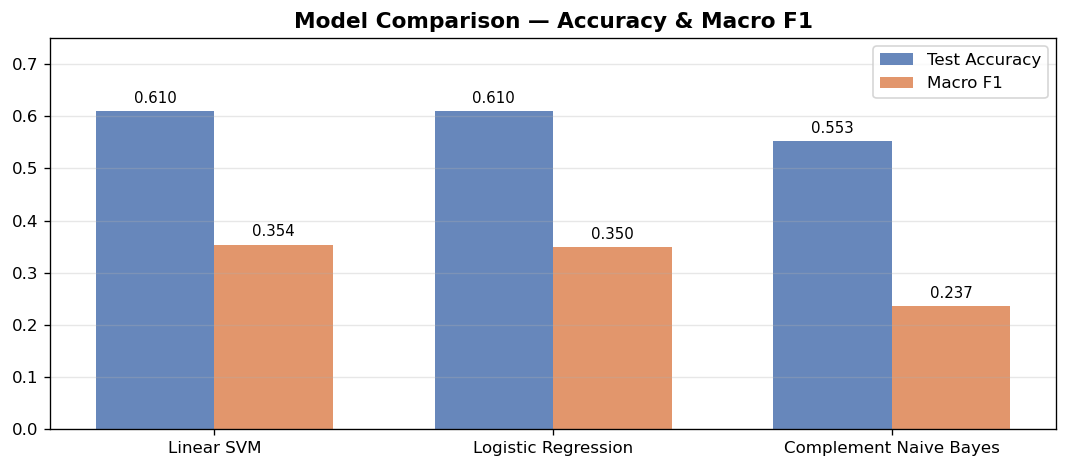

,Test Accuracy,Macro F1,Train Time (s)
Model,,,
Linear SVM,60.97%,0.3540,74.3
Logistic Regression,60.95%,0.3496,276.1
Complement Naive Bayes,55.28%,0.2366,35.1


In [ ]:
fig, ax = plt.subplots(figsize=(9, 4))

names = list(results.keys())
accs  = [results[n]['acc'] for n in names]
f1s   = [results[n]['f1']  for n in names]
x = np.arange(len(names))
w = 0.35

bars1 = ax.bar(x - w/2, accs, w, label='Test Accuracy', color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + w/2, f1s,  w, label='Macro F1',      color='#DD8452', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(names, fontsize=10)
ax.set_ylim(0, 0.75)
ax.set_title('Model Comparison — Accuracy & Macro F1', fontsize=13, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars1, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)
for bar, val in zip(bars2, f1s):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Table
summary = pd.DataFrame({
    'Model': names,
    'Test Accuracy': [f"{results[n]['acc']*100:.2f}%" for n in names],
    'Macro F1':      [f"{results[n]['f1']:.4f}"      for n in names],
    'Train Time (s)':[f"{results[n]['time']:.1f}"    for n in names],
})
display(summary.set_index('Model'))

## 📄 Step 10 — Detailed Classification Report (Best Model)

In [ ]:
best_preds = results[best_name]['preds']

print(f'📄 Classification Report — {best_name}')
print('=' * 65)
print(classification_report(y_test, best_preds, zero_division=0))

📄 Classification Report — Linear SVM
              precision    recall  f1-score   support

      action       0.50      0.34      0.41      1314
       adult       0.67      0.37      0.48       590
   adventure       0.63      0.22      0.32       775
   animation       0.48      0.10      0.17       498
   biography       0.00      0.00      0.00       264
      comedy       0.56      0.62      0.59      7446
       crime       0.30      0.04      0.07       505
 documentary       0.70      0.87      0.77     13096
       drama       0.57      0.76      0.65     13612
      family       0.49      0.13      0.20       783
     fantasy       0.45      0.07      0.12       322
   game-show       0.82      0.68      0.75       193
     history       0.50      0.01      0.02       243
      horror       0.63      0.65      0.64      2204
       music       0.68      0.55      0.61       731
     musical       0.39      0.05      0.10       276
     mystery       0.43      0.03      0.05 

## 📈 Step 11 — Visualizations

### 11a. Confusion Matrix (Top 12 Genres)

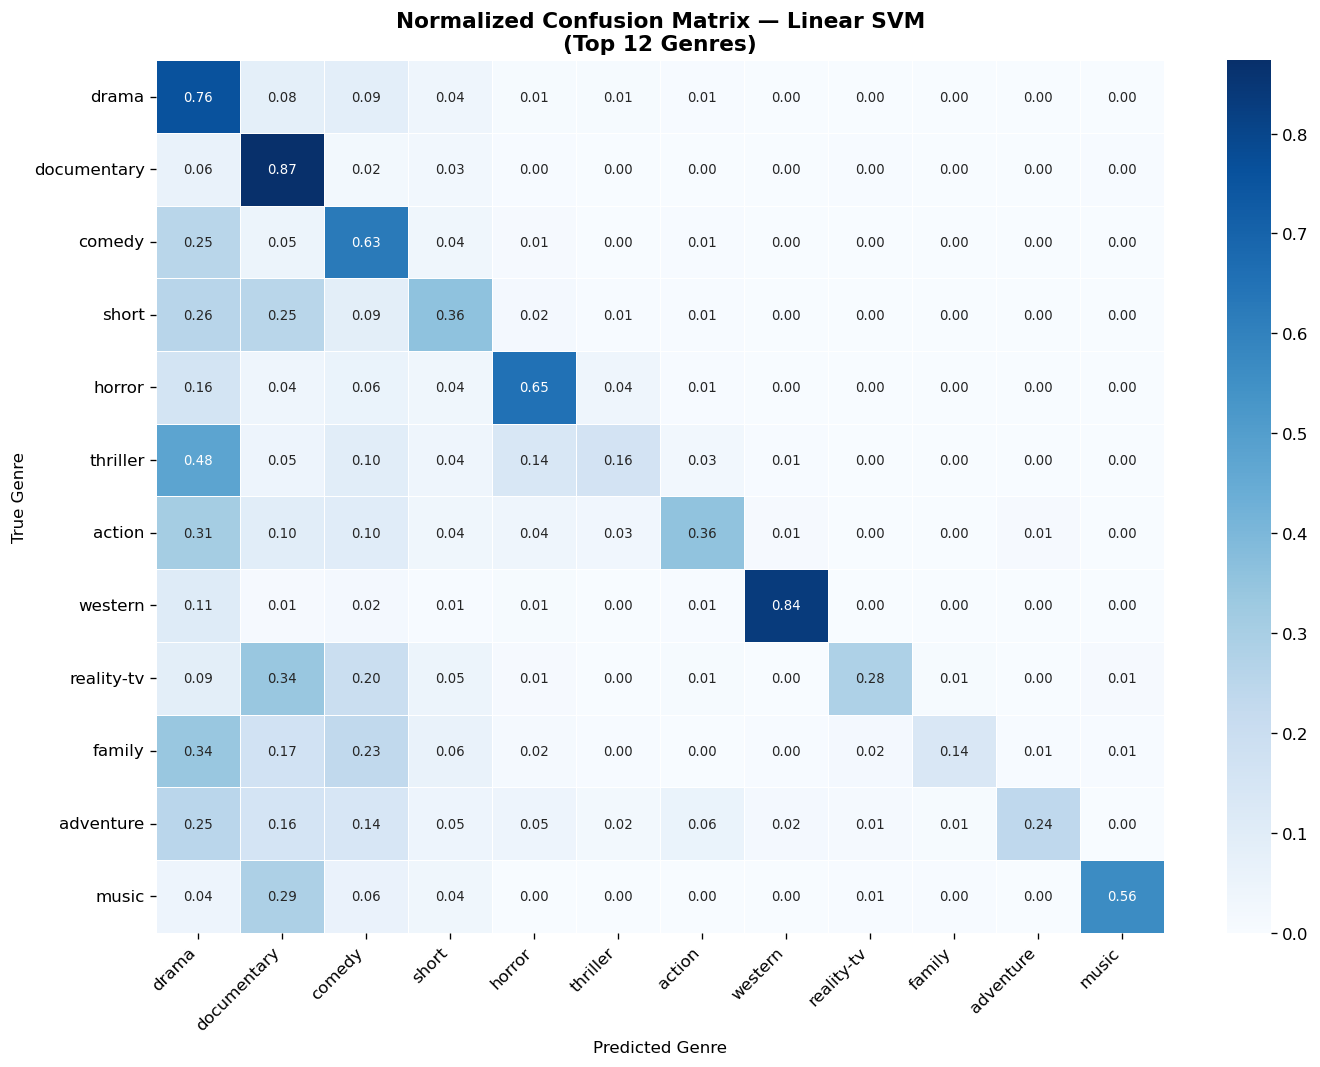

In [ ]:
top_genres = train['genre'].value_counts().head(12).index.tolist()
mask = y_test.isin(top_genres)

cm = confusion_matrix(
    y_test[mask], best_preds[mask],
    labels=top_genres,
    normalize='true'
)

plt.figure(figsize=(12, 9))
sns.heatmap(
    cm, annot=True, fmt='.2f', cmap='Blues',
    xticklabels=top_genres, yticklabels=top_genres,
    linewidths=0.5, annot_kws={'size': 8}
)
plt.title(f'Normalized Confusion Matrix — {best_name}\n(Top 12 Genres)', fontsize=13, fontweight='bold')
plt.xlabel('Predicted Genre')
plt.ylabel('True Genre')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 11b. Per-Genre F1 Score

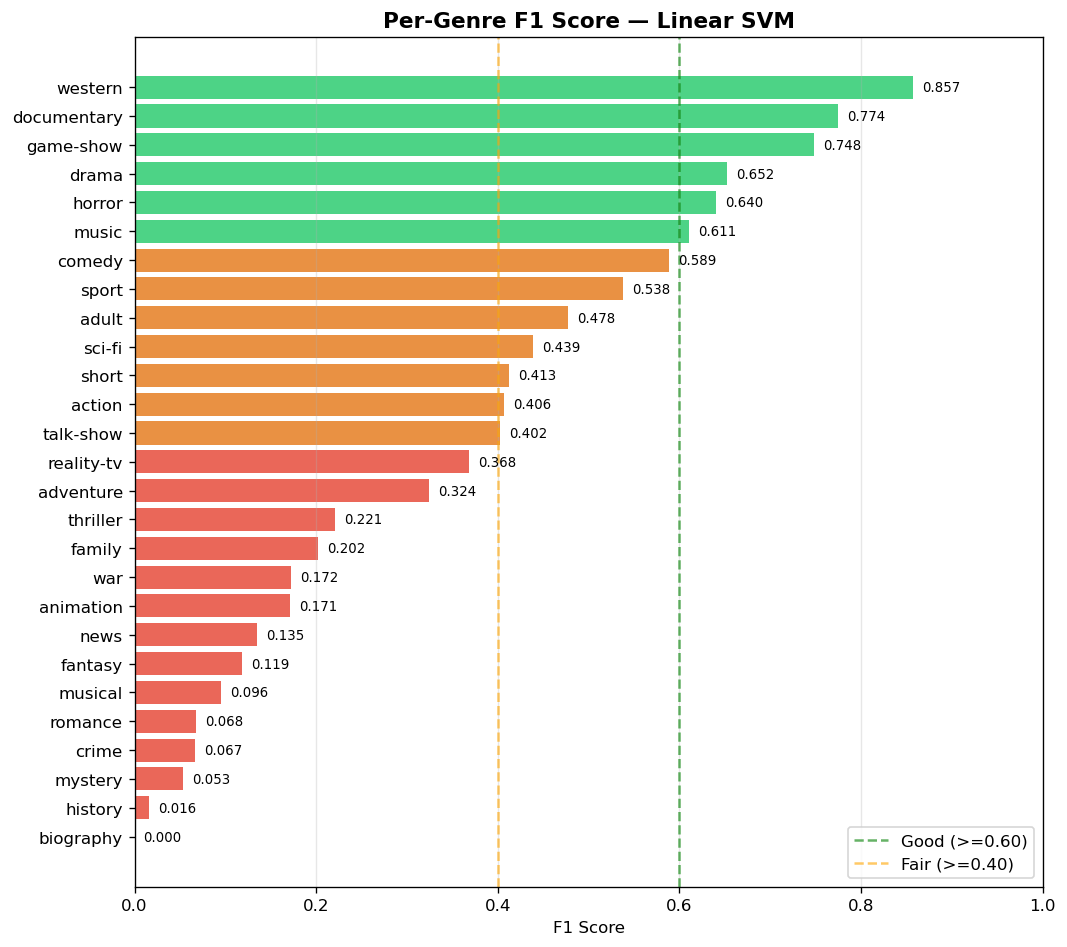

In [ ]:
report_dict = classification_report(y_test, best_preds, output_dict=True, zero_division=0)
genre_f1 = {
    k: v['f1-score']
    for k, v in report_dict.items()
    if k not in ('accuracy', 'macro avg', 'weighted avg')
}
gf1_sorted = dict(sorted(genre_f1.items(), key=lambda x: x[1], reverse=True))

bar_colors = [
    '#2ecc71' if v >= 0.6 else
    '#e67e22' if v >= 0.4 else
    '#e74c3c'
    for v in gf1_sorted.values()
]

plt.figure(figsize=(9, 8))
plt.barh(list(gf1_sorted.keys()), list(gf1_sorted.values()), color=bar_colors, alpha=0.85)
plt.axvline(0.6, color='green',  linestyle='--', alpha=0.6, label='Good (>=0.60)')
plt.axvline(0.4, color='orange', linestyle='--', alpha=0.6, label='Fair (>=0.40)')
plt.xlabel('F1 Score')
plt.title(f'Per-Genre F1 Score — {best_name}', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.xlim(0, 1.0)
plt.legend()
plt.grid(axis='x', alpha=0.3)
for i, (g, f) in enumerate(gf1_sorted.items()):
    plt.text(f + 0.01, i, f'{f:.3f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()

## 💾 Step 12 — Save the Best Model

In [ ]:
best_pipe = models[best_name]
joblib.dump(best_pipe, 'best_genre_model.pkl')

print(f'✅ Model saved: best_genre_model.pkl')
print(f'   Model type : {best_name}')
print(f'   Accuracy   : {results[best_name]["acc"]*100:.2f}%')
print(f'   Macro F1   : {results[best_name]["f1"]:.4f}')

✅ Model saved: best_genre_model.pkl
   Model type : Linear SVM
   Accuracy   : 60.97%
   Macro F1   : 0.3540


## 🎬 Step 13 — Predict Genre on New Movies

Use the trained model to predict genres on any movie description!

In [ ]:
def predict_genre(title, plot, model_path='best_genre_model.pkl'):
    """
    Predict the genre of a movie given its title and plot summary.
    """
    model = joblib.load(model_path)
    text  = clean_text(title) + ' ' + clean_text(plot)
    return model.predict([text])[0].upper()


demo_movies = [
    ('Space Odyssey 2099',
     'A crew of astronauts travels through a wormhole to find a new planet as Earth faces collapse.'),
    ('Laugh Out Loud',
     'A bumbling accountant accidentally becomes a stand-up comedian after hilarious misunderstandings.'),
    ('Shadow of the Killer',
     'A detective hunts a masked serial killer who leaves cryptic clues at each crime scene.'),
    ('Battlefield 1918',
     'Soldiers survive the brutal trenches of World War I and form unbreakable bonds under fire.'),
    ('Wild West Showdown',
     'A lone gunslinger rides into a lawless frontier town to face a ruthless outlaw gang.'),
    ('The Love Triangle',
     'Two best friends fall for the same person, leading to heartbreak, jealousy and unexpected choices.'),
]

print('🎬 Genre Predictions')
print('=' * 52)
for title, plot in demo_movies:
    pred = predict_genre(title, plot)
    print(f'  {title:<32} → {pred}')

🎬 Genre Predictions
  Space Odyssey 2099               → SCI-FI
  Laugh Out Loud                   → COMEDY
  Shadow of the Killer             → THRILLER
  Battlefield 1918                 → DRAMA
  Wild West Showdown               → WESTERN
  The Love Triangle                → DRAMA


## ✅ Step 14 — Final Summary

### Results

| Model | Test Accuracy | Macro F1 |
|---|---|---|
| **Linear SVM** | **~61%** | **~0.35** |
| Logistic Regression | ~61% | ~0.35 |
| Complement Naive Bayes | ~55% | ~0.24 |

### Why accuracy is not higher

- **Class imbalance:** Drama has 50x more samples than Biography
- **Genre overlap:** Romance, Drama, Mystery share very similar vocabulary
- **Short descriptions:** Some movies have only 1-2 sentences of plot info

### How to improve further

- Apply `class_weight='balanced'` to reduce drama over-prediction
- Use **word embeddings** (GloVe, fastText) for semantic understanding
- Fine-tune **DistilBERT** — typically reaches 72-75%+ on this dataset
- Handle multi-label classification (many films belong to 2-3 genres)

---
*Built with scikit-learn · pandas · matplotlib · seaborn*  
*Dataset: IMDb via ftp://ftp.fu-berlin.de/pub/misc/movies/database/*